<a href="https://colab.research.google.com/github/nastya-kolle/math-statistics/blob/main/Math_Statistics_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Критерии проверки статистических гипотез

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy
import scipy.stats as stats
import seaborn as sns

##**1. Сравнение двух дисперсий нормальных генеральных совокупностей**

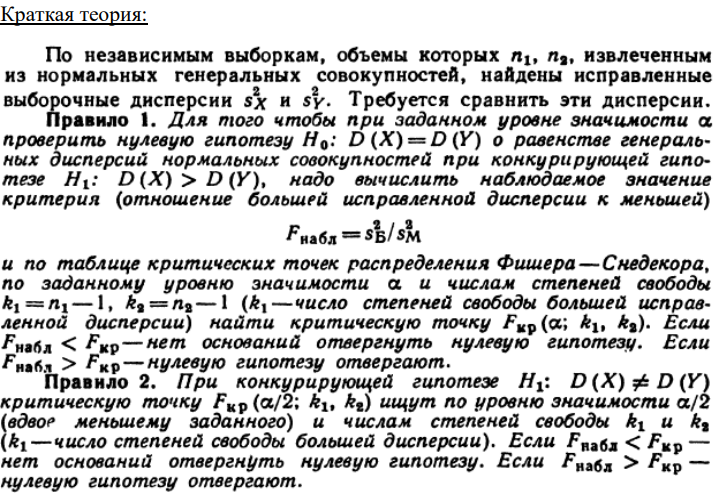

Задания: сгенерировать две выборки из нормального распределения с
произвольными значениями параметров µ и

(на ваш выбор) объемом 100 и
150 элементов. Решить задачу с использованием Правила 1 и Правила 2
(см.выше), то есть подтвердить или опровергнуть основную гипотезу при
уровне значимости 0,05.

Возьмем mu=1 и sigma=3 a=0,05

In [ ]:
mu=1
sigma=3
n=100
X=np.random.normal(mu,sigma,n)
X

array([ 3.30591774,  2.02887193,  4.7803409 ,  0.34273122,  1.94914365,
       -0.49156712,  0.15766776,  4.28531499,  1.788179  ,  1.06328845,
        2.91369463,  2.74495677, -3.16887392,  2.15497513, -1.20050183,
        2.72137082, -3.22354977,  3.45793787,  1.81144425,  7.56330801,
        3.46850736,  3.94061986,  0.305709  ,  3.10660531,  3.34528814,
       -0.8485188 , -2.74008182,  0.40592637, -0.14571891,  1.91721346,
        0.99933885,  4.0380353 , -1.1579871 ,  0.81675165, -1.096836  ,
        0.49678185,  5.81005093, -0.90090705,  3.84508386,  6.47837003,
        1.20430592,  6.76684137, -4.43300539,  1.94685137, -2.75270888,
        2.75581284,  2.67824799,  0.07125752, -2.42813542, -6.3215288 ,
        2.36248674, -1.69447693,  3.82821656,  2.56472777,  6.37060883,
        0.04175585, -0.18931715, -0.01534188,  2.22265716,  4.13810724,
        3.47538388, -0.5915617 ,  2.20073063,  3.25850978, -0.87350322,
       -3.03592429,  6.26312863, -1.35666779,  0.97967736,  3.13

In [ ]:
mu=1
sigma=3
n=150
Y=np.random.normal(mu,sigma,n)
Y

array([ 1.08487971,  2.90918029,  3.17045282, -0.39806519,  0.64665902,
        2.25146766,  2.30943596, -1.67738887, -0.11771849,  3.4811411 ,
       -3.05990692,  5.40082196,  0.87312697, -3.0415156 ,  2.16542257,
       -0.66849476,  2.36798066,  0.2842859 ,  3.29016547,  4.66757131,
        3.92238407,  0.12432101, -1.9372728 , -2.04964982, -1.67065651,
        2.30538233,  2.94414524,  4.91641471,  0.15194012,  0.08271552,
        2.17445927, -1.28290222,  6.21708223, -0.46999786,  1.69386924,
        1.5321322 ,  2.7848398 , -0.57194696,  2.3911947 , -0.29923203,
        4.18538479, -3.65300924, -1.38232569,  1.23554084,  2.84119003,
        1.89200274,  6.82388422,  2.15922886, -5.59929022,  1.07693495,
        0.9572841 ,  3.52487307,  2.01108475, -1.12416012, -3.50766757,
        1.10127203, -2.10806371, -1.67451339, -1.79006223, -2.69939485,
        1.02179564, -4.38650552, -2.56598242, -1.6558401 , -1.47805048,
       -2.98769506,  2.84277929, -1.95109463,  3.36168045,  3.41

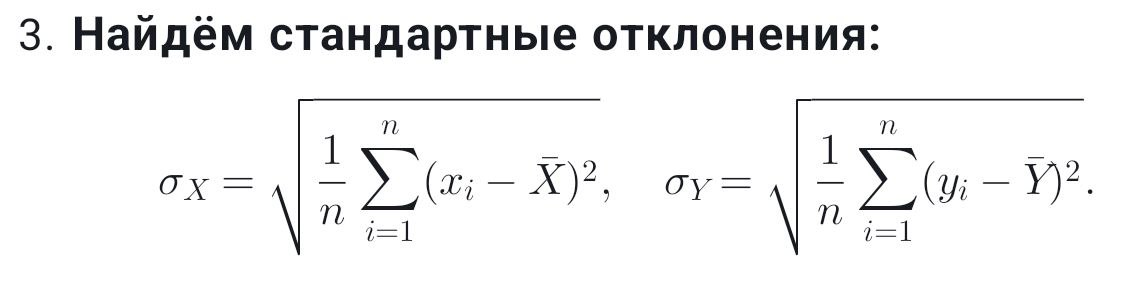

In [ ]:
x_mean=np.mean(X)
x_mean

np.float64(1.457265948359213)

In [ ]:
y_mean=np.mean(Y)
y_mean

np.float64(0.9124204895667593)

In [ ]:
def dispersion_x(X, x_mean):
  sum=0
  for i in range(len(X)):
    res=X[i]-x_mean
    sum+=res**2
  sigma_x=(sum*1.0)/len(X)
  return sigma_x

In [ ]:
def dispersion_y(Y, y_mean):
  sum=0
  for i in range(len(Y)):
    res=Y[i]-y_mean
    sum+=res**2
  sigma_y=(sum*1.0)/len(Y)
  return sigma_y

In [ ]:
sigma_x=dispersion_x(X, x_mean)
sigma_x

np.float64(7.288888424497577)

In [ ]:
sigma_y=dispersion_y(Y, y_mean)
sigma_y

np.float64(8.413192420860524)

In [ ]:
len(Y)

150

* H0 - D[X] = D[Y]
* H1 - D[X] > D[Y]

In [ ]:
def get_F_observe(sigma_x,sigma_y):
  F=sigma_y/(sigma_x*1.0)
  return F

In [ ]:
F_observe=get_F_observe(sigma_x,sigma_y)
F_observe

np.float64(1.1542490337188067)

* k_1 = n_1-1 => k_1 = 150-1=149 для Y D[Y]=9.352
* k_2 = n_2-1 => k_2 = 100-1=99 для X D[X]=9.1804

F_critical(a,k_1,k_2)

In [ ]:
from scipy.stats import f
f_critical=f.ppf(1-0.05,149,99)
f_critical

np.float64(1.3610015887652556)

F_observe = 1.018740 < f_critical = 1.36100 => Принимаем H0 => D[X]=D[Y]

По правилу 2 :
* уровень значимости a/2 => 0.05/2 = 0.025
* k_1 k_2 -число  степеней свободы

In [ ]:
from scipy.stats import f
f_critical=f.ppf(1-0.025,149,99)
f_critical

np.float64(1.444601941210317)

F_observe = 1.018740 < f_critical = 1.444601 => Принимаем H0 => D[X]=D[Y]

##**2. Сравнение двух средних генеральных совокупностей, дисперсии которых известны (большие выборки)**

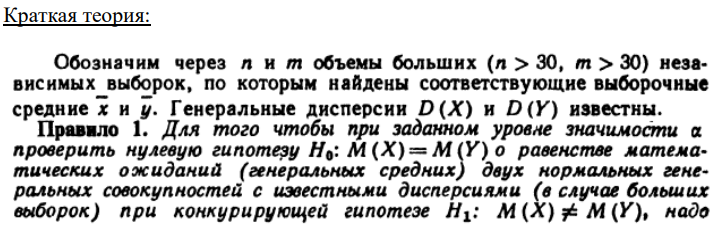

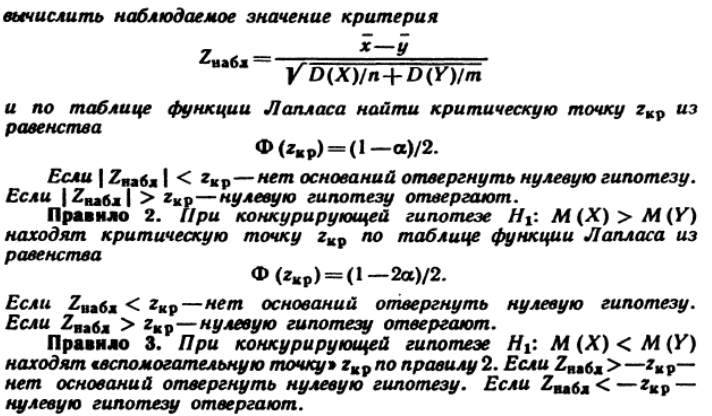

Задания: сгенерировать две выборки из нормального распределения с
произвольными значениями параметров µ и

(на ваш выбор) объемом 100 и
150 элементов. Решить задачу с использованием Правила 1 и Правила 2 и
Правила 3 (см.выше), то есть подтвердить или опровергнуть основную
гипотезу при уровне значимости 0,05.

* H0 - M[X] = M[Y]
* H1 - M[X] <> M[Y]

In [ ]:
def get_z_observe(x_mean, y_mean, X, Y, sigma_x, sigma_y):
  res_1=x_mean-y_mean
  res_2=np.sqrt(sigma_x/(len(X)*1.0)+sigma_y/(len(Y)*1.0))
  Z_obs=res_1/(res_2*1.0)
  return Z_obs

In [ ]:
z_observe=get_z_observe(x_mean, y_mean, X, Y, sigma_x, sigma_y)
z_observe

np.float64(1.51711142838176)

F(z_critical)=(1-a)/2 => F(z_critical)=0.95/2=0,475

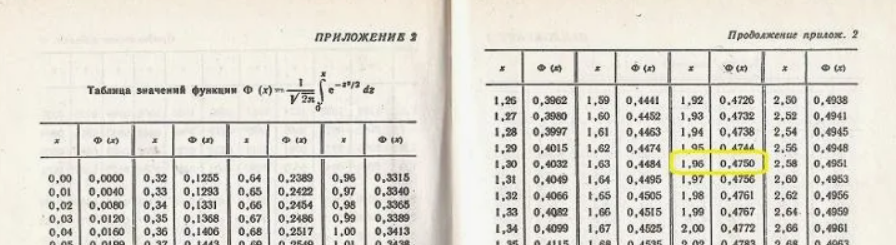

z_observe = 1.558 < z_critical = 1,96 => Принимаем H0 => M[X]=M[Y]

По правилу 2 F(z_critical)=(1-2*a)/2 => F(z_critical)=0.9/2=0,45

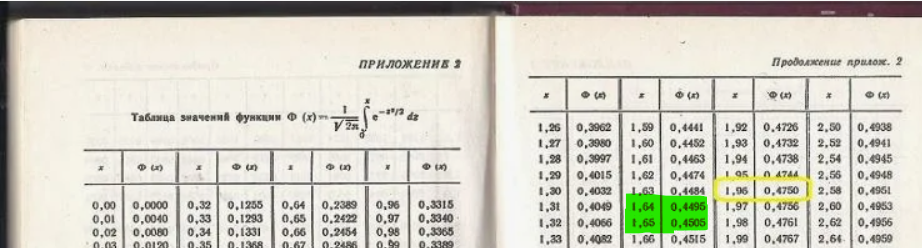

z_observe = 1.517 < z_critical = 1,645 => Принимаем H0 => M[X]=M[Y]

По правилу 3 z_observe = 1.517 > -(z_critical = 1,645) => Принимаем H0 => M[X]=M[Y]

##**3. Сравнение нескольких дисперсий нормальных генеральных совокупностей по выборкам различного объема. Критерий Бартлетта**

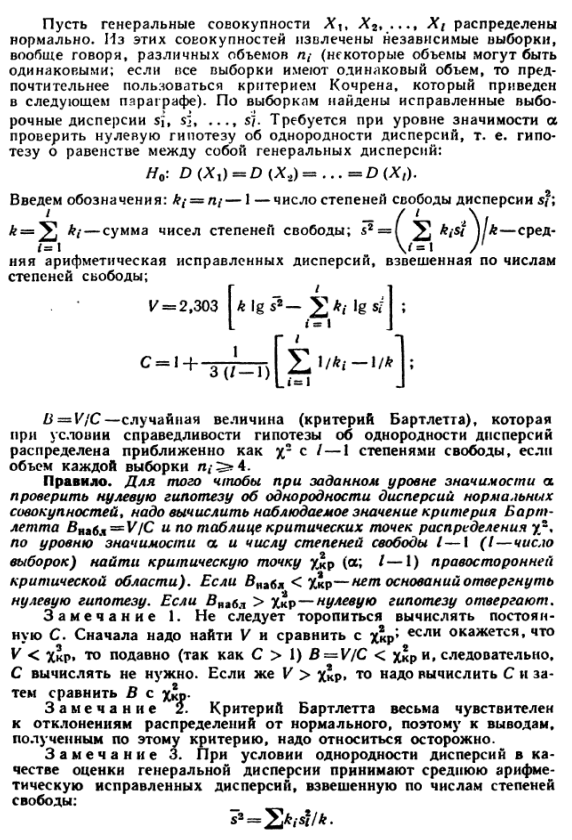

Задания: сгенерировать пять выборок из нормального распределения так,
чтобы параметр

у них был одинаковый, а параметр µ выберете произвольно,
но так, чтобы для каждой выборки было свое значение. Объемы выборок 50,
60, 70, 80, 90. Подтвердить или опровергнуть основную гипотезу при уровне
значимости 0,05.

Возьмем выборки при sigma=3 и mu=1,2,3,4,5

In [ ]:
mu=1
sigma=3
n=50
X_1=np.random.normal(mu,sigma,n)
X_1

array([ 4.50822768,  3.92589557, -0.70895554,  0.52182516, -2.08545819,
        4.54553831,  2.73581645, -0.75628462,  4.86399807,  0.8978779 ,
       -2.12085331,  3.75957785, -0.77519494, -3.08173868,  1.41349112,
        0.91808224,  0.42995775,  2.8642337 ,  1.67959131,  6.40835453,
        3.44336922, -0.59985518, -3.12755885, -9.72726784, -1.64851503,
       -2.73031649, -3.30189633,  4.78593883,  3.3135614 ,  4.30994346,
        1.15535755,  1.2216673 ,  5.08072409,  5.69159034,  0.83920941,
        6.99245095,  1.72199286,  7.47674835, -0.70676206,  2.16313483,
        3.74229411,  1.85908008,  3.53275442,  1.75627371,  1.96593461,
        1.81734432,  5.92724307,  0.01418499, -2.65676408, -4.42909397])

In [ ]:
mu=2
sigma=3
n=60
X_2=np.random.normal(mu,sigma,n)
X_2

array([ 0.37929118,  1.38516548,  1.28402061,  2.14856159,  2.35405969,
        5.86346004, -3.08795894,  2.83393975,  4.48527627,  7.46199913,
       -0.90005554,  0.39125688,  0.06106805, -2.51625973,  1.26179005,
       -0.68268884,  5.40093543,  1.11652787,  0.1781642 , -0.90002373,
       -4.36812571,  2.47169818,  5.67242826,  7.4505605 ,  4.56915574,
       -0.22774436,  6.24644912,  2.5509628 ,  1.92828224, -2.46246117,
        0.51094786,  5.84860503, -1.5064197 ,  0.02815408,  8.65266749,
       -1.07530499, -4.34143221,  4.07483203,  1.86317877,  5.93290092,
        9.62874738,  0.03977911,  2.85143916, -0.32371047, -3.00802365,
       -0.6315787 , -0.79941526, -3.01882938,  7.36250477,  3.06444781,
       -0.90836138,  0.53201848,  3.08500885,  6.6467143 ,  1.73847182,
       -5.3668096 ,  1.92647197, -2.87817945,  9.3124447 ,  3.27581856])

In [ ]:
mu=3
sigma=3
n=70
X_3=np.random.normal(mu,sigma,n)
X_3

array([ 1.43283324,  3.0720903 ,  2.83574632,  4.47130796,  4.88982893,
        4.6317855 ,  2.74496725,  0.05268046,  9.72365012,  3.88796611,
        2.12497014, -0.36549544,  2.52271724,  6.03899926,  2.12673256,
        4.92910399,  7.59291858,  6.5679068 ,  2.72113199,  5.27183323,
        7.0687383 , -2.37605809,  0.37682538,  2.49440389,  3.54905119,
       -3.76665908,  4.32656813,  0.87501574,  4.10319442, 10.05867009,
        7.71891067, -1.45771485,  3.2017793 ,  3.38219204,  1.99684914,
        3.53922331,  2.10219678,  4.38547531,  2.88016713,  5.37765616,
        1.02690241,  5.5024895 ,  6.98032588,  8.73706967,  1.10170468,
        3.02648648, -1.00352695,  4.143824  ,  4.46319936, -2.59601961,
        1.73874958,  1.48023378,  3.06613106,  4.47915206,  1.15308802,
        3.85486873,  2.26292551, -0.20512715,  5.72238552,  5.81967743,
        2.79006208,  3.85545061,  1.31562216,  9.47352023,  1.81173764,
        8.44146129,  6.53128125,  3.34247716,  4.54752791,  4.66

In [ ]:
mu=4
sigma=3
n=80
X_4=np.random.normal(mu,sigma,n)
X_4

array([ 2.67710692,  3.5039569 ,  4.75348057,  0.5969644 ,  5.184759  ,
        0.09883886,  4.47903273,  8.41540729,  3.68771138,  6.1703985 ,
        7.83212842,  2.63606422,  8.85374043,  3.84831448,  3.97235367,
        1.86407997,  7.42284838,  5.34165271, -0.30064558,  5.16984194,
        6.25331374,  6.04885243,  4.92996417,  2.35191024, 10.69888039,
        8.56434599, 10.82610998,  4.34770564,  8.03115979,  2.82613503,
        1.16412064,  1.27595661,  7.59601022,  3.25611759,  5.77592142,
        5.93875275,  4.74104536,  4.43447257,  3.53889328,  2.45078226,
        2.51338524,  3.32351092,  2.22494492,  5.23958013,  2.95563807,
        3.41013651,  0.35683614,  1.25211033,  3.05845207,  1.70427577,
       10.29161214,  5.96445025,  6.4182226 ,  6.05977277,  3.74813948,
        8.49033146,  4.63412058,  8.50848516,  3.53603094, -0.01424895,
        7.66913518,  4.65095037,  3.53599211,  2.09557195,  0.51263479,
        1.49613369, 11.52008348, -0.34877153,  3.28252978,  7.92

In [ ]:
mu=5
sigma=3
n=90
X_5=np.random.normal(mu,sigma,n)
X_5

array([ 3.32802071,  6.66719571,  4.55024087,  6.18668922,  2.56858155,
        6.48565605,  9.68624011, 10.55449498,  7.06331842,  4.62581379,
        7.91246771,  7.11024547, 13.07266766,  4.87994963,  6.99917841,
        2.10643209,  4.05277025,  0.78457737,  4.55423246,  2.26582318,
        7.32057158,  0.57614843,  0.89243893, -0.48267173,  8.59242178,
       -0.20798088,  7.66369731,  3.40291236,  9.36910365,  2.85366979,
        1.9508533 ,  2.02715512,  5.15424612,  0.87479126,  9.13422097,
       -0.91767373,  2.88099424,  6.02814542,  5.72169731,  4.88844124,
        5.75070404,  8.101574  ,  5.4922797 ,  4.94607175,  2.17235769,
        3.92710887,  4.80288315,  1.81677748,  2.52670452,  2.82977523,
        6.37273418,  4.34425682,  2.14228068,  6.5997906 ,  8.00368631,
        4.72409181,  5.30736215,  4.98329852,  7.09365163,  6.55159369,
        8.171482  ,  5.65394695,  3.31755175,  3.52295756,  5.30113347,
        0.38118981,  7.01771057,  8.30026104,  2.46012647,  7.24

In [ ]:
def get_mean(distribution):
  return np.mean(distribution)

In [ ]:
X_1_mean = get_mean(X_1)
X_1_mean

np.float64(1.3965350084153214)

In [ ]:
X_2_mean = get_mean(X_2)
X_2_mean

np.float64(1.747780388970387)

In [ ]:
X_3_mean = get_mean(X_3)
X_3_mean

np.float64(3.4948076791557607)

In [ ]:
X_4_mean = get_mean(X_4)
X_4_mean

np.float64(4.417857659965742)

In [ ]:
X_5_mean = get_mean(X_5)
X_5_mean

np.float64(4.664083129074239)

In [ ]:
def dispersion_distribution(distribution, distribution_mean):
  sum=0
  for i in range(len(distribution)):
    res=distribution[i]-distribution_mean
    sum+=res**2
  sigma_distribution=(sum*1.0)/len(distribution)
  return sigma_distribution

In [ ]:
dipersion_x_1=dispersion_distribution(X_1, X_1_mean)
dipersion_x_1

np.float64(10.94421172605049)

In [ ]:
dipersion_x_2=dispersion_distribution(X_2, X_2_mean)
dipersion_x_2

np.float64(12.579480678939586)

In [ ]:
dipersion_x_3=dispersion_distribution(X_3, X_3_mean)
dipersion_x_3

np.float64(8.080368774576765)

In [ ]:
dipersion_x_4=dispersion_distribution(X_4, X_4_mean)
dipersion_x_4

np.float64(8.72646065203933)

In [ ]:
dipersion_x_5=dispersion_distribution(X_5, X_5_mean)
dipersion_x_5

np.float64(7.754326178177537)

* H0 D[X_1]=D[X_2]=D[X_3]=D[X_4]=D[X_5]
* число степеней свободы:
  * D[X_1] = 10.944 k_1 = 49
  * D[X_2] = 12.579 k_2 = 59
  * D[X_3] = 8.0803 k_3 = 69
  * D[X_4] = 8.726 k_4 = 79
  * D[X_5] = 7.754 k_5 = 89


In [ ]:
k=49+59+69+79+89
k

345

In [ ]:
K=[49,59,69,79,89]
K

[49, 59, 69, 79, 89]

In [ ]:
dispersion=[dipersion_x_1,dipersion_x_2,dipersion_x_3,dipersion_x_4,dipersion_x_5]
dispersion

[np.float64(10.94421172605049),
 np.float64(12.579480678939586),
 np.float64(8.080368774576765),
 np.float64(8.72646065203933),
 np.float64(7.754326178177537)]

In [ ]:
def get_mean_s(K, dispersion):
  sum=0
  for i in range(len(K)):
    sum+=K[i]*dispersion[i]
  res=sum/(k*1.0)
  return res

In [ ]:
mean_s=get_mean_s(K, dispersion)
mean_s

np.float64(9.320366960720621)

In [ ]:
def get_V(k,mean_s, dispersion, K):
  res_1=k*math.log10(mean_s)
  sum=0
  for i in range(len(dispersion)):
    sum+=K[i]*math.log10(dispersion[i])
  res_2=res_1-sum
  res=res_2*2.303
  return res

In [ ]:
V=get_V(k,mean_s, dispersion, K)
V

5.863122913423795

Проверим по замечанию 1 нужно ли считать C

* уровень знвчимости a=0.05
* число степеней свободы l-1 = 4

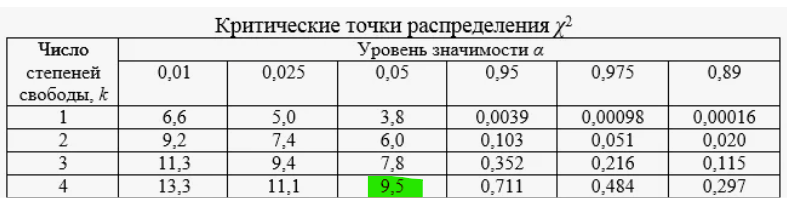

* V = 5.863 < X_2_critical = 9,5 => то подавно B=V/C < X_2_critical => Не нужно вычислять C
* B=V/C < X_2_critical => Принимаем H0 => D[X_1]=D[X_2]=D[X_3]=D[X_4]=D[X_5]